# Análise de viagens a serviço — camada Gold

Este notebook responde às sete perguntas de negócio sobre a camada Silver e cria as agregações da Gold. Execute primeiro as etapas 0–2 do pipeline. A Parte A consulta diretamente a Silver. A Parte B cria e atualiza as tabelas Gold e views PostgreSQL e responde quatro perguntas restantes.

As credenciais são carregadas da configuração existente e do arquivo .env. Não inclua credenciais nas células. A base recebida corresponde a seis meses de 2025: o notebook exibe o intervalo realmente encontrado, sem presumir meses com base nas datas de viagem.

valor_total é calculado na Silver como diárias + passagens − devoluções + outros gastos. duracao_dias é a diferença entre data final e inicial, sem adicionar um dia.


In [23]:
"""Prepara o ambiente analítico e define consultas com conexões curtas.

Define auxiliares para consultar SQL, relatar rankings e desenhar gráficos.
Também verifica as tabelas Silver necessárias e resume o intervalo e a
qualidade dos dados antes das análises."""
from pathlib import Path
from contextlib import closing
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

raiz = Path.cwd()
if not (raiz / "postgresql").is_dir():
    raiz = raiz.parent
if not (raiz / "postgresql").is_dir():
    raise RuntimeError("Abra este notebook a partir da raiz do projeto ou da pasta postgresql.")
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from postgresql.banco import conectar

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.figsize": (10, 5)})

def consultar(sql_texto, parametros=None):
    """Consulta PostgreSQL e encerra a conexão mesmo se houver erro."""
    with closing(conectar()) as conexao:
        conexao.set_session(isolation_level="REPEATABLE READ", readonly=True)
        with conexao:
            with conexao.cursor() as cursor:
                cursor.execute(sql_texto, parametros)
                return pd.DataFrame(
                    cursor.fetchall(), columns=[c.name for c in cursor.description]
                )

def classificar(dados, limite, unidade):
    """Exibe até limite linhas, todos os líderes e empate no corte."""
    validos = dados.dropna(subset=["valor"]).reset_index(drop=True)
    if validos.empty:
        print("Sem valores informados para calcular o ranking.")
        return validos
    tabela = validos.head(limite)
    display(tabela)
    maior = validos.iloc[0]["valor"]
    lideres = validos.loc[validos["valor"] == maior, "categoria"].tolist()
    corte = tabela.iloc[-1]["valor"]
    empate_corte = validos.iloc[limite:].loc[
        lambda x: x["valor"] == corte, "categoria"
    ].tolist()
    print(f"Maior resultado: {maior} {unidade}. Líder(es): {lideres}.")
    if empate_corte:
        print(f"Empatados no corte e não exibidos: {empate_corte}.")
    if len(validos) < len(dados):
        print(f"Categorias sem valor calculável: {len(dados) - len(validos)}.")
    return tabela

def grafico_barras(dados, titulo, rotulo_x, unidade):
    """Converte números para float apenas para visualização."""
    if dados.empty:
        print("Sem categorias para o gráfico.")
        return
    desenho = dados.iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, max(4, len(desenho) * 0.42 + 1.5)))
    ax.barh(desenho["categoria"].astype(str), desenho["valor"].astype(float),
            label=unidade, color="#2878B5")
    ax.set(title=titulo, xlabel=rotulo_x, ylabel="Categoria")
    ax.legend(title="Métrica")
    ax.grid(axis="x", alpha=0.2)
    fig.tight_layout()
    plt.show()

versao = consultar("SHOW server_version")
print("PostgreSQL", versao.iloc[0, 0])
for tabela in ("silver_viagem", "silver_pagamento", "silver_trecho"):
    existente = consultar("SELECT to_regclass(%s) AS tabela", (tabela,))
    if existente.iloc[0, 0] is None:
        raise RuntimeError(f"{tabela} não existe; execute primeiro as etapas 0–2.")

contagens = consultar("""
SELECT (SELECT count(*) FROM silver_viagem) AS viagens,
       (SELECT count(*) FROM silver_pagamento) AS pagamentos,
       (SELECT count(*) FROM silver_trecho) AS trechos
""")
display(contagens)
if (contagens.iloc[0] == 0).any():
    raise RuntimeError("Uma tabela Silver necessária está vazia.")

qualidade = consultar("""
SELECT count(*) AS viagens,
       min(data_inicio) AS primeira_data_inicio,
       max(data_inicio) AS ultima_data_inicio,
       min(data_fim) AS primeira_data_fim,
       max(data_fim) AS ultima_data_fim,
       count(*) FILTER (WHERE duracao_dias IS NULL) AS duracoes_nulas,
       count(*) FILTER (WHERE duracao_dias < 0) AS duracoes_negativas,
       count(*) FILTER (WHERE valor_total IS NULL) AS custos_nulos,
       count(*) FILTER (WHERE nullif(btrim(destinos), '') IS NULL) AS destinos_ausentes,
       count(*) FILTER (WHERE nullif(btrim(nome_orgao_superior), '') IS NULL) AS orgaos_ausentes
FROM silver_viagem
""")
display(qualidade)
print("Ausências são reportadas; valores não informados não viram zero.")


PostgreSQL 15.19


,viagens,pagamentos,trechos
0,341860,606916,763349


,viagens,primeira_data_inicio,ultima_data_inicio,primeira_data_fim,ultima_data_fim,duracoes_nulas,duracoes_negativas,custos_nulos,destinos_ausentes,orgaos_ausentes
0,341860,2025-01-01,2025-06-30,2025-01-01,2026-04-05,0,0,0,0,0


Ausências são reportadas; valores não informados não viram zero.


## Parte A — análises diretamente na Silver

As tabelas mostram os rankings pedidos, com ordenação decrescente e nome como desempate. O texto identifica todos os líderes empatados e eventuais empates no limite.


### 1. Quais são os cinco órgãos superiores com maior custo total?

Métrica: soma de valor_total por nome_orgao_superior. Custos nulos não contribuem para a soma. Órgãos ausentes ficam fora do ranking.


,categoria,valor,qtd_viagens,qtd_viagens_com_custo
0,Ministério da Justiça e Segurança Pública,485748241.43,75324,75324
1,Ministério da Defesa,154595910.29,61369,61369
2,Ministério da Educação,109759836.03,64757,64757
3,Ministério do Meio Ambiente e Mudança do Clima,49300595.26,19291,19291
4,Ministério da Previdência Social,40236180.79,8129,8129


Maior resultado: 485748241.43 R$. Líder(es): ['Ministério da Justiça e Segurança Pública'].


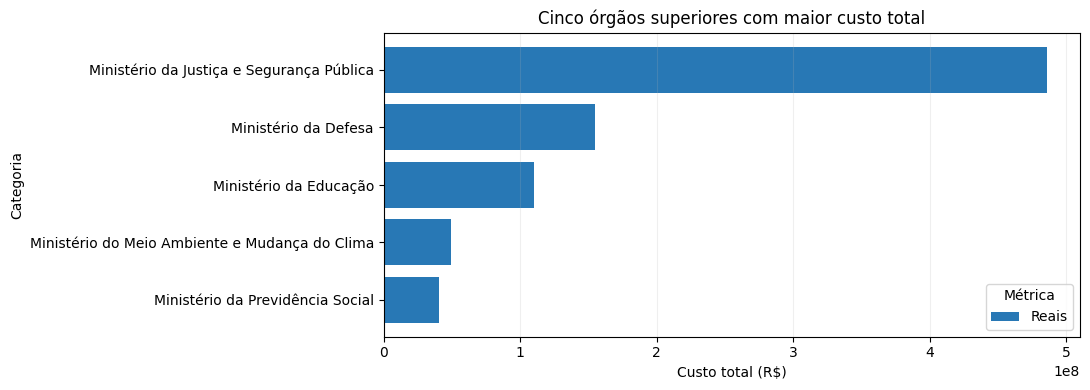

Foram encontrados 35 órgãos. O custo no primeiro lugar foi R$ 485,748,241.43.


In [24]:
"""Consulta o custo total e o número de viagens por órgão superior.

Ordena pelo custo decrescente e usa o nome como critério de desempate."""
sql_orgaos = """
SELECT btrim(nome_orgao_superior) AS categoria,
       sum(valor_total) AS valor, count(*) AS qtd_viagens,
       count(valor_total) AS qtd_viagens_com_custo
FROM silver_viagem
WHERE nullif(btrim(nome_orgao_superior), '') IS NOT NULL
  AND situacao = 'Realizada'
GROUP BY btrim(nome_orgao_superior)
ORDER BY valor DESC NULLS LAST, categoria
"""
orgaos = consultar(sql_orgaos)
top_orgaos = classificar(orgaos, 5, "R$")
grafico_barras(top_orgaos, "Cinco órgãos superiores com maior custo total",
               "Custo total (R$)", "Reais")
if not top_orgaos.empty:
    print(f"Foram encontrados {len(orgaos)} órgãos. "
          f"O custo no primeiro lugar foi R$ {top_orgaos.iloc[0]['valor']:,.2f}.")


### 2. Quais são os três itinerários com maior custo médio por viagem?

Destino significa o itinerário completo no campo silver_viagem.destinos. A média usa viagens com valor_total informado; exibimos a quantidade total e a que entrou no cálculo.


,categoria,valor,qtd_viagens,qtd_valores_informados
0,"Brasília/DF, Brasília/DF",27401.797561837456,283,283
1,Genebra/Suíça,25469.222314049587,242,242
2,Nova York/Estados Unidos da América,21214.192214765101,149,149


Maior resultado: 27401.797561837456 R$/viagem. Líder(es): ['Brasília/DF, Brasília/DF'].


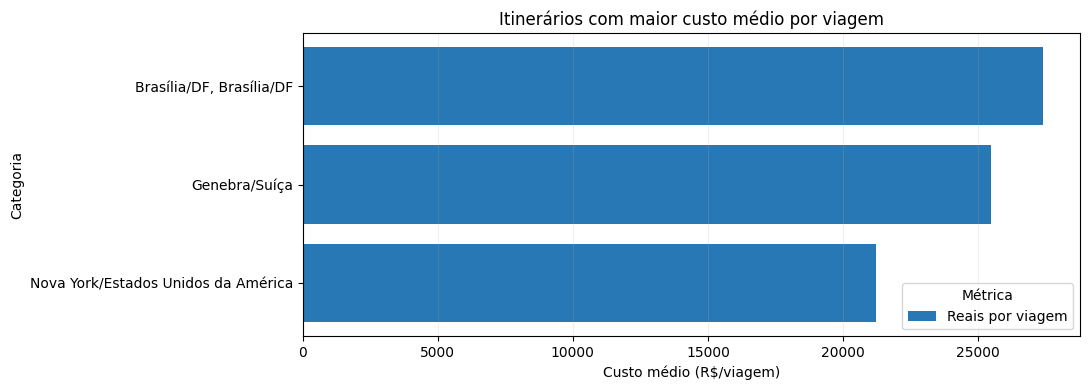

Itinerário líder: 'Brasília/DF, Brasília/DF', R$ 27,401.80; 283 de 283 viagens com custo informado.


In [25]:
"""Calcula custo médio por itinerário completo e conta viagens válidas.

A média ignora custos nulos; itinerários ausentes são excluídos."""
sql_destinos = """
SELECT btrim(destinos) AS categoria, avg(valor_total) AS valor,
       count(*) AS qtd_viagens, count(valor_total) AS qtd_valores_informados
FROM silver_viagem
WHERE nullif(btrim(destinos), '') IS NOT NULL
  AND situacao = 'Realizada'
GROUP BY btrim(destinos)
HAVING COUNT(*) >= 100
ORDER BY valor DESC NULLS LAST, categoria
"""
destinos = consultar(sql_destinos)
top_destinos = classificar(destinos, 3, "R$/viagem")
grafico_barras(top_destinos, "Itinerários com maior custo médio por viagem",
               "Custo médio (R$/viagem)", "Reais por viagem")
if not top_destinos.empty:
    r = top_destinos.iloc[0]
    print(f"Itinerário líder: {r['categoria']!r}, R$ {r['valor']:,.2f}; "
          f"{r['qtd_valores_informados']} de {r['qtd_viagens']} viagens com custo informado.")


### 3. Qual foi a viagem mais longa e qual seu custo total?

Durações nulas ou negativas não definem a viagem mais longa. São exibidas todas as viagens empatadas na duração máxima. Os painéis separam dias e reais.


,id_viagem,duracao_dias,valor_total
0,0000000000020699856,384,0.00
1,0000000000020793594,379,120650.00
2,0000000000020774569,370,0.00
3,0000000000020793492,370,113382.50
4,0000000000020592696,367,159044.90


Máximo: 384 dias; 5 viagem(ns) empatada(s); custos ausentes: 0.


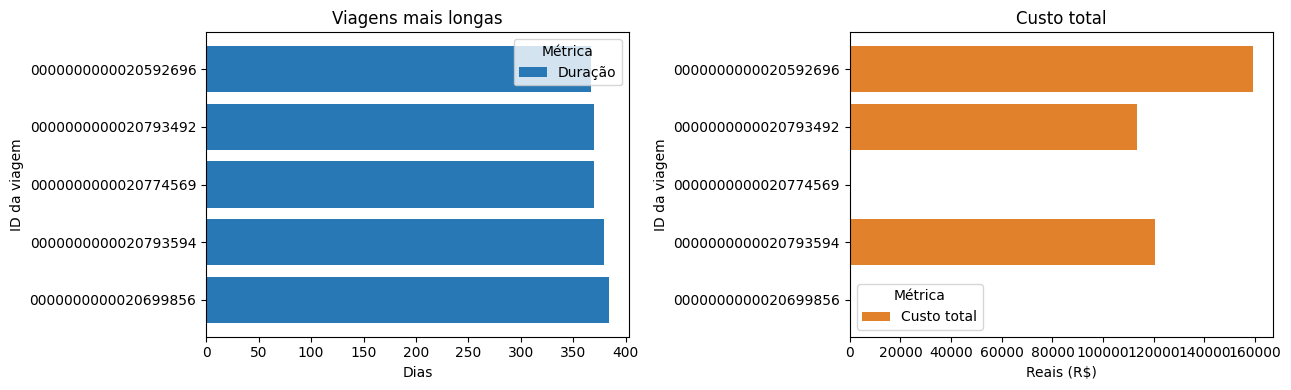

In [26]:
"""Localiza a viagem com a maior duração não negativa.

Apresenta os custos e separa dias e reais nos painéis do gráfico."""
sql_duracao = """
SELECT id_viagem, duracao_dias, valor_total
FROM silver_viagem
WHERE situacao = 'Realizada' AND duracao_dias >= 0
ORDER BY duracao_dias DESC NULLS LAST, id_viagem
LIMIT 5
"""
mais_longas = consultar(sql_duracao)
if mais_longas.empty:
    print("Não há durações válidas.")
else:
    display(mais_longas)
    print(f"Máximo: {mais_longas.iloc[0]['duracao_dias']} dias; "
          f"{len(mais_longas)} viagem(ns) empatada(s); "
          f"custos ausentes: {mais_longas['valor_total'].isna().sum()}.")
    fig, eixos = plt.subplots(1, 2, figsize=(13, max(4, len(mais_longas) * .4 + 1.5)))
    eixos[0].barh(mais_longas["id_viagem"].astype(str), mais_longas["duracao_dias"],
                  label="Duração", color="#2878B5")
    eixos[0].set(title="Viagens mais longas", xlabel="Dias", ylabel="ID da viagem")
    eixos[0].legend(title="Métrica")
    custos = mais_longas.dropna(subset=["valor_total"])
    if custos.empty:
        eixos[1].text(.5, .5, "Custo não informado", ha="center", va="center",
                      transform=eixos[1].transAxes)
    else:
        eixos[1].barh(custos["id_viagem"].astype(str), custos["valor_total"].astype(float),
                      label="Custo total", color="#E1812C")
        eixos[1].legend(title="Métrica")
    eixos[1].set(title="Custo total", xlabel="Reais (R$)", ylabel="ID da viagem")
    fig.tight_layout()
    plt.show()


## Parte B — agregações e análises Gold

gold_pagamentos tem granularidade órgão pagador + tipo de pagamento. gold_trechos tem granularidade UF de destino + meio de transporte. Cada view junta apenas sua tabela-filha à viagem; pagamentos não são unidos a trechos, para evitar multiplicação de valores e contagens.

As views refletem a Silver em cada consulta. As tabelas são fotografias agregadas, atualizadas integralmente nesta Parte B. Execute-a de novo após uma nova carga Silver.


### Esquema SQL das tabelas e views

Dimensões vazias ou compostas de espaços são normalizadas para NULL nas agregações, sem alterar a Silver. Pagamentos sem valor informado entram nas contagens. Se nenhum pagamento do grupo tiver valor informado, seu total será NULL. A função abaixo fornece o DDL, que só é executado dentro da transação de atualização.


In [27]:
"""Declara o esquema das agregações Gold e suas views PostgreSQL.

As views agrupam pagamentos e trechos separadamente para evitar
multiplicação de registros e manter dimensões ausentes como NULL."""
def obter_ddl_gold():
    """Retorna o DDL Gold para execução na transação de atualização."""
    return """
CREATE TABLE IF NOT EXISTS gold_pagamentos (
    nome_orgao_pagador TEXT,
    tipo_pagamento TEXT,
    qtd_pagamentos BIGINT NOT NULL,
    qtd_valores_informados BIGINT NOT NULL,
    valor_total NUMERIC,
    CONSTRAINT chk_gold_pagamentos_quantidades CHECK (
        qtd_pagamentos > 0 AND qtd_valores_informados >= 0
        AND qtd_valores_informados <= qtd_pagamentos
    ),
    CONSTRAINT chk_gold_pagamentos_valor CHECK (
        (qtd_valores_informados = 0 AND valor_total IS NULL)
        OR (qtd_valores_informados > 0 AND valor_total IS NOT NULL
            AND valor_total >= 0 AND valor_total = round(valor_total, 2))
    )
);
CREATE TABLE IF NOT EXISTS gold_trechos (
    destino_uf TEXT,
    meio_transporte TEXT,
    qtd_trechos BIGINT NOT NULL,
    CONSTRAINT chk_gold_trechos_quantidade CHECK (qtd_trechos > 0)
);
CREATE OR REPLACE VIEW vw_gold_pagamentos AS
SELECT nullif(btrim(p.nome_orgao_pagador), '') AS nome_orgao_pagador,
       nullif(btrim(p.tipo_pagamento), '') AS tipo_pagamento,
       count(*) AS qtd_pagamentos, count(p.valor) AS qtd_valores_informados,
       sum(p.valor) AS valor_total
FROM silver_pagamento p
INNER JOIN silver_viagem v ON v.id_viagem = p.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY 1, 2;
CREATE OR REPLACE VIEW vw_gold_trechos AS
SELECT nullif(btrim(t.destino_uf), '') AS destino_uf,
       nullif(btrim(t.meio_transporte), '') AS meio_transporte,
       count(*) AS qtd_trechos
FROM silver_trecho t
INNER JOIN silver_viagem v ON v.id_viagem = t.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY 1, 2;
"""
print(obter_ddl_gold())



CREATE TABLE IF NOT EXISTS gold_pagamentos (
    nome_orgao_pagador TEXT,
    tipo_pagamento TEXT,
    qtd_pagamentos BIGINT NOT NULL,
    qtd_valores_informados BIGINT NOT NULL,
    valor_total NUMERIC,
    CONSTRAINT chk_gold_pagamentos_quantidades CHECK (
        qtd_pagamentos > 0 AND qtd_valores_informados >= 0
        AND qtd_valores_informados <= qtd_pagamentos
    ),
    CONSTRAINT chk_gold_pagamentos_valor CHECK (
        (qtd_valores_informados = 0 AND valor_total IS NULL)
        OR (qtd_valores_informados > 0 AND valor_total IS NOT NULL
            AND valor_total >= 0 AND valor_total = round(valor_total, 2))
    )
);
CREATE TABLE IF NOT EXISTS gold_trechos (
    destino_uf TEXT,
    meio_transporte TEXT,
    qtd_trechos BIGINT NOT NULL,
    CONSTRAINT chk_gold_trechos_quantidade CHECK (qtd_trechos > 0)
);
CREATE OR REPLACE VIEW vw_gold_pagamentos AS
SELECT nullif(btrim(p.nome_orgao_pagador), '') AS nome_orgao_pagador,
       nullif(btrim(p.tipo_pagamento), '') AS tipo_pag

### Atualização integral, atômica e validações

A transação verifica fontes não vazias, integridade referencial e compatibilidade das tabelas Gold existentes. Atualiza views, substitui somente os conteúdos Gold e valida grupos, igualdade com as views, totais, contagens e médias antes do commit. Erros revertem a transação; estruturas incompatíveis falham antes de excluir dados.


In [28]:
"""Atualiza as tabelas Gold atomicamente e confere sua reconciliação.

Valida fontes e esquema, publica as views, recarrega os agregados e
compara grupos, totais, contagens e médias antes de confirmar."""
from psycopg2 import sql

# Esta conexão pertence somente a esta execução e sempre é encerrada no finally.
conexao = conectar()

try:
    conexao.set_session(isolation_level="REPEATABLE READ", readonly=False)
    with conexao.cursor() as cursor:
        cursor.execute("SET LOCAL lock_timeout = '10s'")
        cursor.execute("SET LOCAL statement_timeout = '180s'")
        cursor.execute("SELECT current_schema()")
        schema = cursor.fetchone()[0]
        if schema is None:
            raise RuntimeError("Não há schema ativo.")
        cursor.execute("SELECT pg_try_advisory_xact_lock(hashtext(%s))",
                       ("notebook_gold:" + schema,))
        if not cursor.fetchone()[0]:
            raise RuntimeError("Outra atualização Gold está em andamento.")
        cursor.execute(sql.SQL(
            "LOCK TABLE silver_viagem, silver_pagamento, silver_trecho IN SHARE MODE"
        ))
        cursor.execute("""
            SELECT
              (SELECT count(*) FROM silver_viagem),
              (SELECT count(*) FROM silver_pagamento),
              (SELECT count(*) FROM silver_trecho),
              (SELECT count(*) FROM silver_pagamento p
               LEFT JOIN silver_viagem v USING (id_viagem) WHERE v.id_viagem IS NULL),
              (SELECT count(*) FROM silver_trecho t
               LEFT JOIN silver_viagem v USING (id_viagem) WHERE v.id_viagem IS NULL)
        """)
        nv, npag, ntrc, opag, otrc = cursor.fetchone()
        if not nv or not npag or not ntrc:
            raise RuntimeError("Uma fonte Silver está vazia.")
        if opag or otrc:
            raise RuntimeError(f"Há órfãos: {opag} pagamentos e {otrc} trechos.")

        # A criação/atualização das views e o restante da operação pertencem à transação.
        cursor.execute(obter_ddl_gold())
        esquemas = {
            "gold_pagamentos": [
                ("nome_orgao_pagador", "text", False),
                ("tipo_pagamento", "text", False),
                ("qtd_pagamentos", "bigint", True),
                ("qtd_valores_informados", "bigint", True),
                ("valor_total", "numeric", False)],
            "gold_trechos": [
                ("destino_uf", "text", False),
                ("meio_transporte", "text", False),
                ("qtd_trechos", "bigint", True)]}
        checks = {
            "gold_pagamentos": {"chk_gold_pagamentos_quantidades",
                                "chk_gold_pagamentos_valor"},
            "gold_trechos": {"chk_gold_trechos_quantidade"}}
        for tabela, esperado in esquemas.items():
            cursor.execute("""
                SELECT attname, format_type(atttypid, atttypmod), attnotnull
                FROM pg_attribute
                WHERE attrelid = to_regclass(%s) AND attnum > 0 AND NOT attisdropped
                ORDER BY attnum
            """, (tabela,))
            if cursor.fetchall() != esperado:
                raise RuntimeError(f"Esquema incompatível em {tabela}; dados preservados.")
            cursor.execute("""
                SELECT conname FROM pg_constraint
                WHERE conrelid = to_regclass(%s) AND contype = 'c' AND convalidated
            """, (tabela,))
            if not checks[tabela].issubset({r[0] for r in cursor.fetchall()}):
                raise RuntimeError(f"Constraints incompatíveis em {tabela}; dados preservados.")

        cursor.execute("DELETE FROM gold_pagamentos")
        cursor.execute("DELETE FROM gold_trechos")
        cursor.execute("""
            INSERT INTO gold_pagamentos
                (nome_orgao_pagador, tipo_pagamento, qtd_pagamentos,
                 qtd_valores_informados, valor_total)
            SELECT nome_orgao_pagador, tipo_pagamento, qtd_pagamentos,
                   qtd_valores_informados, valor_total FROM vw_gold_pagamentos
        """)
        cursor.execute("""
            INSERT INTO gold_trechos (destino_uf, meio_transporte, qtd_trechos)
            SELECT destino_uf, meio_transporte, qtd_trechos FROM vw_gold_trechos
        """)
        for tabela, dimensoes in (
            ("gold_pagamentos", "nome_orgao_pagador, tipo_pagamento"),
            ("gold_trechos", "destino_uf, meio_transporte")):
            cursor.execute(
                f"SELECT 1 FROM {tabela} GROUP BY {dimensoes} HAVING count(*) > 1")
            if cursor.fetchone():
                raise RuntimeError(f"Há grupos repetidos em {tabela}.")
            cursor.execute(f"""
                SELECT EXISTS (
                    (SELECT * FROM {tabela} EXCEPT ALL SELECT * FROM vw_{tabela})
                    UNION ALL
                    (SELECT * FROM vw_{tabela} EXCEPT ALL SELECT * FROM {tabela}))
            """)
            if cursor.fetchone()[0]:
                raise RuntimeError(f"Tabela e view divergem em {tabela}.")

        cursor.execute("""
            SELECT
              (SELECT count(*) FROM silver_pagamento p
               JOIN silver_viagem v USING (id_viagem)
               WHERE v.situacao = 'Realizada') =
                (SELECT coalesce(sum(qtd_pagamentos), 0) FROM gold_pagamentos),
              (SELECT count(p.valor) FROM silver_pagamento p
               JOIN silver_viagem v USING (id_viagem)
               WHERE v.situacao = 'Realizada') =
                (SELECT coalesce(sum(qtd_valores_informados), 0) FROM gold_pagamentos),
              (SELECT sum(p.valor) FROM silver_pagamento p
               JOIN silver_viagem v USING (id_viagem)
               WHERE v.situacao = 'Realizada') IS NOT DISTINCT FROM
                (SELECT sum(valor_total) FROM gold_pagamentos),
              (SELECT count(*) FROM silver_trecho t
               JOIN silver_viagem v USING (id_viagem)
               WHERE v.situacao = 'Realizada') =
                (SELECT coalesce(sum(qtd_trechos), 0) FROM gold_trechos)
        """)
        if not all(cursor.fetchone()):
            raise RuntimeError("Contagens ou totais Gold não reconciliam com Silver.")
        cursor.execute("""
            WITH s AS (
                SELECT nullif(btrim(p.tipo_pagamento), '') AS tipo, avg(p.valor) AS media
                FROM silver_pagamento p
                JOIN silver_viagem v USING (id_viagem)
                WHERE v.situacao = 'Realizada'
                GROUP BY 1),
            g AS (
                SELECT tipo_pagamento AS tipo,
                       sum(valor_total) / nullif(sum(qtd_valores_informados), 0) AS media
                FROM gold_pagamentos GROUP BY 1)
            SELECT EXISTS (
                (SELECT * FROM s EXCEPT ALL SELECT * FROM g)
                UNION ALL (SELECT * FROM g EXCEPT ALL SELECT * FROM s))
        """)
        if cursor.fetchone()[0]:
            raise RuntimeError("Médias por tipo de pagamento divergem da Silver.")
        cursor.execute("SELECT count(*) FROM gold_pagamentos")
        grupos_pagamentos = cursor.fetchone()[0]
        cursor.execute("SELECT count(*) FROM gold_trechos")
        grupos_trechos = cursor.fetchone()[0]
    conexao.commit()
except Exception:
    conexao.rollback()
    raise
finally:
    conexao.close()

print(f"Gold atualizada no schema {schema!r}: {grupos_pagamentos:,} grupos de pagamentos "
      f"e {grupos_trechos:,} grupos de trechos.")
print("Conferidos: órfãos, constraints, grupos, views, totais, contagens e médias.")


Gold atualizada no schema 'public': 655 grupos de pagamentos e 201 grupos de trechos.
Conferidos: órfãos, constraints, grupos, views, totais, contagens e médias.


### Ausências preservadas na Gold

As categorias ausentes são contadas à parte. Ausência de UF não tira um trecho do ranking de transporte; ausência de transporte não tira o trecho do ranking de UF.


In [29]:
"""Conta dimensões e valores ausentes preservados nas tabelas Gold.

Cada contagem usa sua própria dimensão para não descartar observações
que ainda têm a outra dimensão informada."""
sql_ausencias = """
SELECT 'Órgão pagador ausente' AS categoria,
       coalesce(sum(qtd_pagamentos), 0) AS quantidade, 'pagamentos' AS unidade
FROM gold_pagamentos WHERE nome_orgao_pagador IS NULL
UNION ALL
SELECT 'Tipo de pagamento ausente', coalesce(sum(qtd_pagamentos), 0), 'pagamentos'
FROM gold_pagamentos WHERE tipo_pagamento IS NULL
UNION ALL
SELECT 'Valor de pagamento ausente',
       coalesce(sum(qtd_pagamentos - qtd_valores_informados), 0), 'pagamentos'
FROM gold_pagamentos
UNION ALL
SELECT 'UF ausente', coalesce(sum(qtd_trechos), 0), 'trechos'
FROM gold_trechos WHERE destino_uf IS NULL
UNION ALL
SELECT 'Transporte ausente', coalesce(sum(qtd_trechos), 0), 'trechos'
FROM gold_trechos WHERE meio_transporte IS NULL
"""
display(consultar(sql_ausencias))


,categoria,quantidade,unidade
0,Órgão pagador ausente,0,pagamentos
1,Tipo de pagamento ausente,0,pagamentos
2,Valor de pagamento ausente,0,pagamentos
3,UF ausente,14505,trechos
4,Transporte ausente,0,trechos


### 4. Qual tipo de pagamento tem maior valor médio?

A média é calculada como soma dos valores informados dividida pela quantidade de valores informados. Tipos sem valores conhecidos não participam do ranking.


,categoria,valor,qtd_pagamentos,qtd_valores_informados
0,DIÁRIAS,2078.7876447932381533,400364,400364
1,PASSAGEM,1882.3176200631004522,182883,182883
2,Serviço correlato: seguro,447.2568970557527668,4789,4789
3,RESTITUIÇÃO,245.7026101607050285,11574,11574


Maior resultado: 2078.7876447932381533 R$/pagamento. Líder(es): ['DIÁRIAS'].


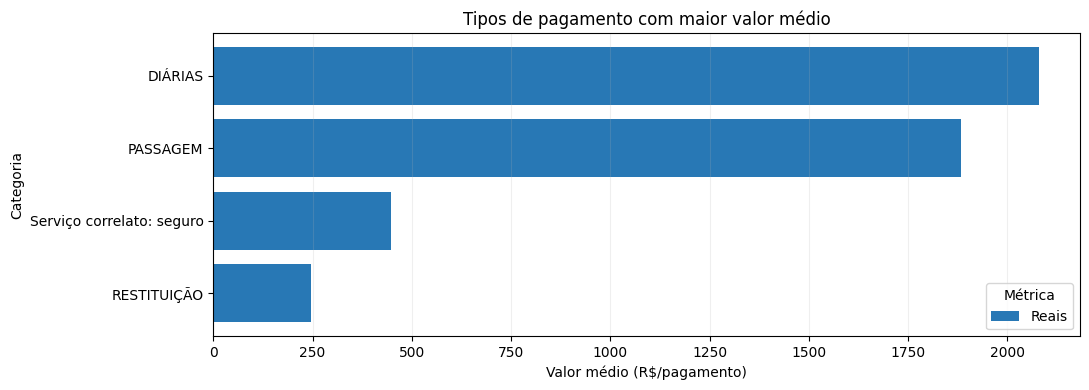

In [30]:
"""Reconstrói a média por tipo a partir das somas e contagens Gold.

O denominador inclui somente pagamentos com valor informado."""
sql_media_pagamento = """
SELECT tipo_pagamento AS categoria,
       sum(valor_total) / nullif(sum(qtd_valores_informados), 0) AS valor,
       sum(qtd_pagamentos) AS qtd_pagamentos,
       sum(qtd_valores_informados) AS qtd_valores_informados
FROM gold_pagamentos
WHERE tipo_pagamento IS NOT NULL
GROUP BY tipo_pagamento
ORDER BY valor DESC NULLS LAST, categoria
"""
medias_pagamento = consultar(sql_media_pagamento)
top_medias = classificar(medias_pagamento, 10, "R$/pagamento")
grafico_barras(top_medias, "Tipos de pagamento com maior valor médio",
               "Valor médio (R$/pagamento)", "Reais")


### 5. Qual meio de transporte é mais usado nos trechos?

Somamos trechos por transporte, incluindo os que não têm UF conhecida.


,categoria,valor
0,Veículo Oficial,385734
1,Aéreo,226707
2,Rodoviário,64454
3,Veículo Próprio,42736
4,Inválido,26523
5,Fluvial,8392
6,Ferroviário,868
7,Marítimo,471


Maior resultado: 385734 trechos. Líder(es): ['Veículo Oficial'].


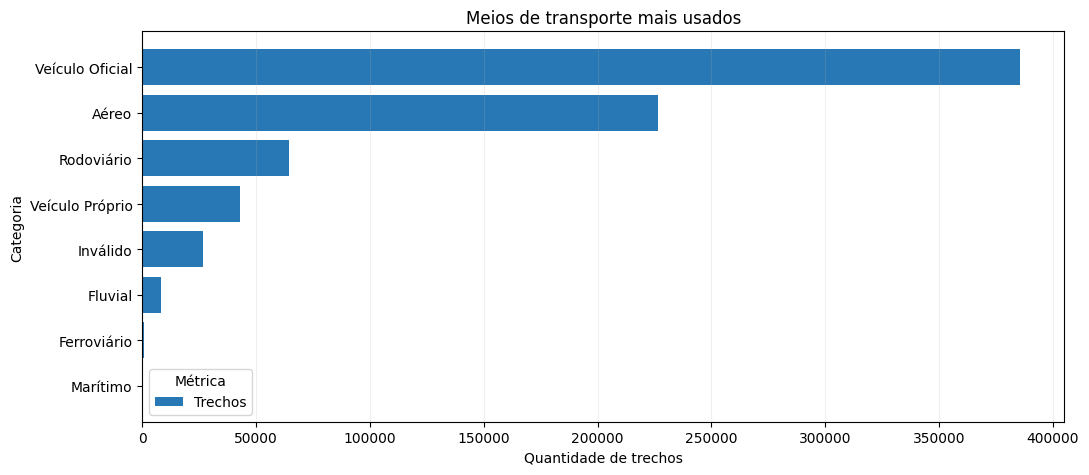

In [31]:
"""Soma os trechos agrupados para classificar meios de transporte.

Inclui trechos sem UF conhecida quando o meio está informado."""
sql_transportes = """
SELECT meio_transporte AS categoria, sum(qtd_trechos) AS valor
FROM gold_trechos WHERE meio_transporte IS NOT NULL
GROUP BY meio_transporte ORDER BY valor DESC, categoria
"""
transportes = consultar(sql_transportes)
top_transportes = classificar(transportes, 10, "trechos")
grafico_barras(top_transportes, "Meios de transporte mais usados",
               "Quantidade de trechos", "Trechos")


### 6. Qual UF de destino aparece em mais trechos?

Contamos por UF, incluindo trechos sem meio de transporte; UFs ausentes são apresentadas na tabela de qualidade.


,categoria,valor
0,São Paulo,81727
1,Distrito Federal,77962
2,Minas Gerais,50555
3,Rio de Janeiro,43481
4,Paraná,42323
5,Pará,39742
6,Rio Grande do Sul,38397
7,Mato Grosso do Sul,30450
8,Bahia,28141
9,Pernambuco,28117


Maior resultado: 81727 trechos. Líder(es): ['São Paulo'].


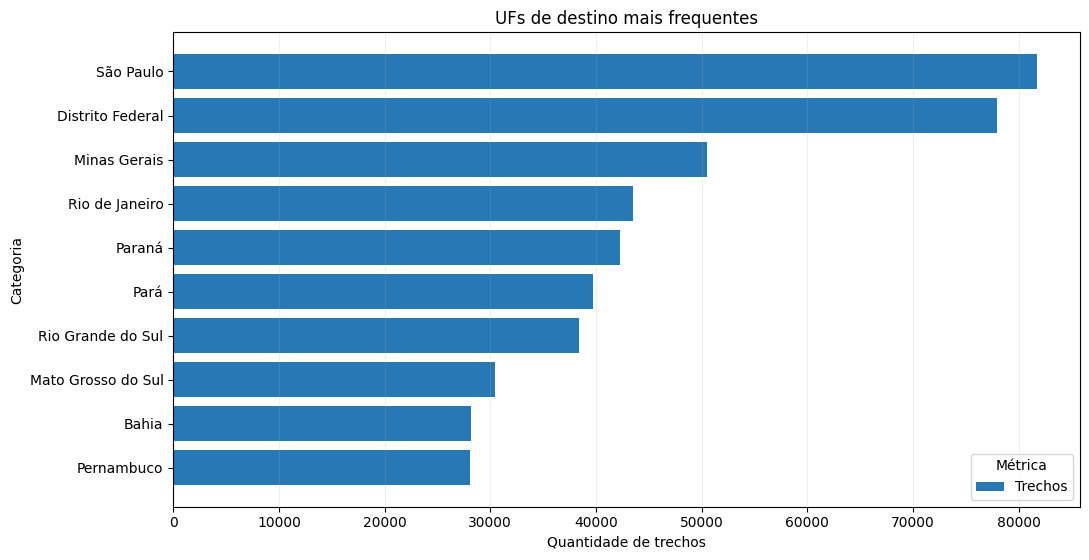

In [32]:
"""Soma os trechos Gold por UF de destino e ordena por frequência.

Trechos sem transporte informado continuam incluídos na contagem."""
sql_ufs = """
SELECT destino_uf AS categoria, sum(qtd_trechos) AS valor
FROM gold_trechos WHERE destino_uf IS NOT NULL
GROUP BY destino_uf ORDER BY valor DESC, categoria
"""
ufs = consultar(sql_ufs)
top_ufs = classificar(ufs, 10, "trechos")
grafico_barras(top_ufs, "UFs de destino mais frequentes",
               "Quantidade de trechos", "Trechos")


### 7. Qual órgão pagador recebeu o maior valor total?

Somamos o valor pago por órgão. Pagamentos sem valor informado continuam nas contagens, mas não aumentam a soma monetária.


,categoria,valor,qtd_pagamentos,qtd_valores_informados
0,Fundo Nacional de Segurança Pública,278288685.42,79715,79715
1,Sigiloso,199308482.09,92452,92452
2,Comando da Aeronáutica,81069602.67,45807,45807
3,Instituto Nacional do Seguro Social,37254697.89,18224,18224
4,Comando do Exército,36576135.70,22607,22607
5,Ministério da Gestão e da Inovação em Serviços...,34464632.12,19617,19617
6,Instituto Brasileiro do Meio Ambiente e dos Re...,31395742.54,16633,16633
7,Ministério das Relações Exteriores - Unidades ...,24939840.86,3619,3619
8,Receita Federal do Brasil,23474664.79,18623,18623
9,Ministério da Agricultura e Pecuária - Unidade...,22497534.01,15676,15676


Maior resultado: 278288685.42 R$. Líder(es): ['Fundo Nacional de Segurança Pública'].


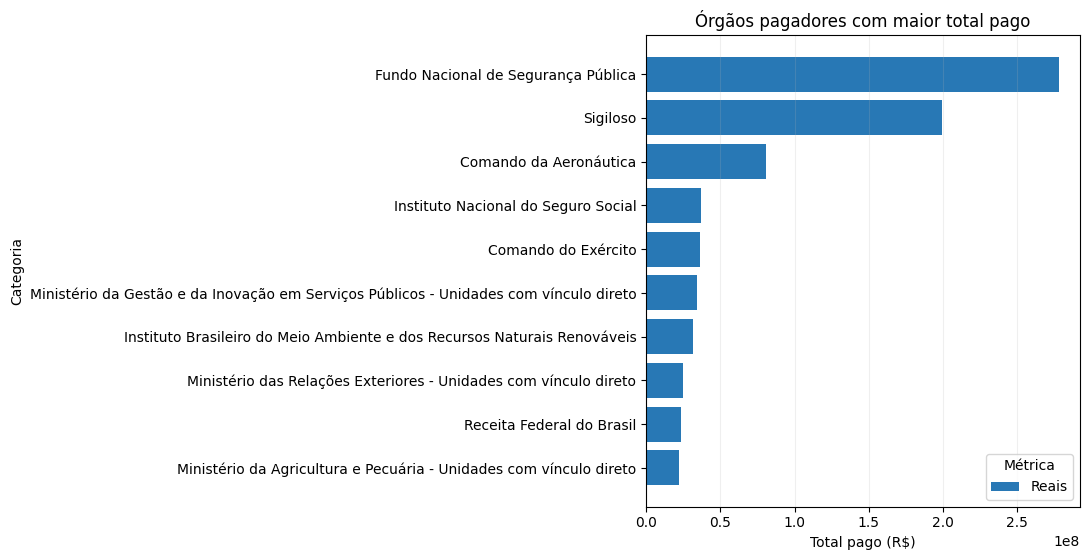

In [33]:
"""Agrega o total pago por órgão pagador para responder a última pergunta.

Pagamentos sem valor ficam na contagem, mas não somam custo."""
sql_orgaos_pagadores = """
SELECT nome_orgao_pagador AS categoria, sum(valor_total) AS valor,
       sum(qtd_pagamentos) AS qtd_pagamentos,
       sum(qtd_valores_informados) AS qtd_valores_informados
FROM gold_pagamentos
WHERE nome_orgao_pagador IS NOT NULL
GROUP BY nome_orgao_pagador
ORDER BY valor DESC NULLS LAST, categoria
"""
orgaos_pagadores = consultar(sql_orgaos_pagadores)
top_orgaos_pagadores = classificar(orgaos_pagadores, 10, "R$")
grafico_barras(top_orgaos_pagadores, "Órgãos pagadores com maior total pago",
               "Total pago (R$)", "Reais")


## Conclusões

Registre no README os achados exibidos nas tabelas e gráficos, a cobertura temporal observada e limitações causadas por dados ausentes. O notebook não antecipa resultados antes da consulta.

Fonte dos dados: arquivos de viagens, pagamentos e trechos do Portal da Transparência processados nas camadas deste projeto. Fontes técnicas: documentação oficial [PostgreSQL 15 — CREATE TABLE](https://www.postgresql.org/docs/15/sql-createtable.html), [CREATE VIEW](https://www.postgresql.org/docs/15/sql-createview.html), [funções agregadas](https://www.postgresql.org/docs/15/functions-aggregate.html) e [constraints](https://www.postgresql.org/docs/15/ddl-constraints.html).
